In [1]:
# Download from: kaggle.com/datasets/nowke9/ipldata
# Files: deliveries.csv, matches.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

deliveries = pd.read_csv('deliveries.csv')
matches    = pd.read_csv('matches.csv')

print("Deliveries:", deliveries.shape)  # ~179k rows
print("Matches:   ", matches.shape)     # ~756 rows
print(deliveries.columns.tolist())
print(matches.columns.tolist())

# Merge on match_id to bring in date, city, result etc.
df = deliveries.merge(
    matches[['id', 'season', 'city', 'winner', 'toss_winner',
             'toss_decision', 'player_of_match']],
    left_on='match_id', right_on='id', how='left'
)
print("Merged shape:", df.shape)

Deliveries: (179078, 21)
Matches:    (756, 18)
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs', 'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed', 'dismissal_kind', 'fielder']
['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3']
Merged shape: (179078, 28)


          batsman  total_runs
0         V Kohli        5434
1        SK Raina        5415
2       RG Sharma        4914
3       DA Warner        4741
4        S Dhawan        4632
5        CH Gayle        4560
6        MS Dhoni        4477
7      RV Uthappa        4446
8  AB de Villiers        4428
9       G Gambhir        4223


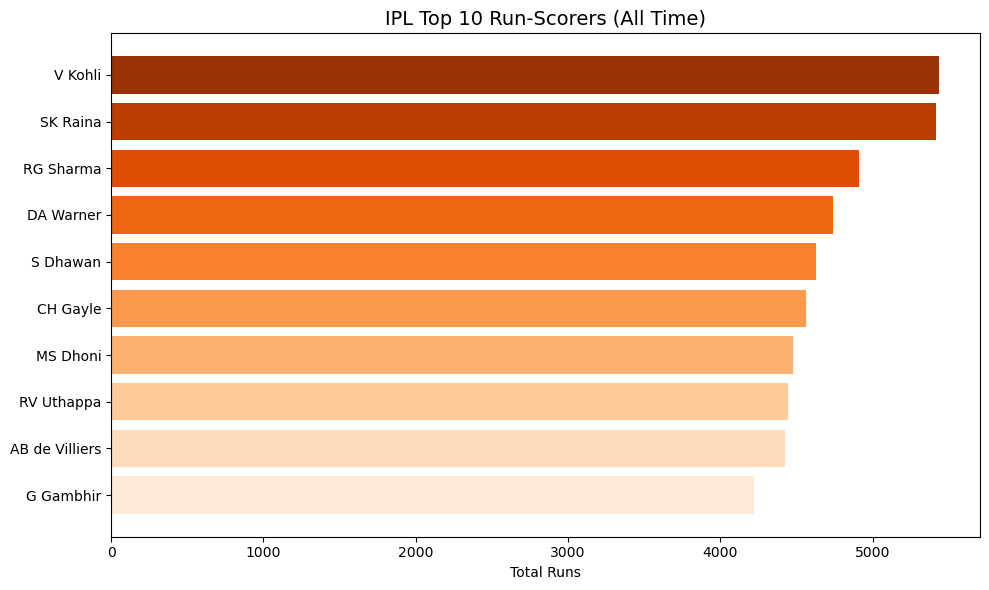

In [2]:
# Top 10 all-time run-scorers
top_scorers = (
    deliveries
    .groupby('batsman')['batsman_runs']
    .sum()
    .nlargest(10)
    .reset_index()
    .rename(columns={'batsman_runs': 'total_runs'})
)
print(top_scorers)

# Add innings count and average
innings = deliveries.groupby('batsman')['match_id'].nunique().reset_index()
innings.columns = ['batsman', 'innings']
top_scorers = top_scorers.merge(innings, on='batsman')
top_scorers['avg_per_innings'] = (
    top_scorers['total_runs'] / top_scorers['innings']
).round(1)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_scorers['batsman'], top_scorers['total_runs'],
    color=sns.color_palette('Oranges_r', 10))
ax.set_title('IPL Top 10 Run-Scorers (All Time)', fontsize=14)
ax.set_xlabel('Total Runs')
ax.invert_yaxis()                     # highest on top
plt.tight_layout()
plt.savefig('ipl_01_scorers.png', dpi=150)
plt.show()

              bowler       overs  runs  wickets  economy
365    Sohail Tanvir   44.166667   275       24     6.23
1         A Chandila   39.000000   245       11     6.28
110       FH Edwards   25.000000   160        6     6.40
191          L Ngidi   27.166667   175       13     6.44
344  SMSM Senanayake   32.500000   211        9     6.49
144          J Yadav   37.666667   248        5     6.58
343       SM Pollock   46.666667   307       13     6.58
6           A Kumble  163.833333  1089       49     6.65
108         DW Steyn  367.833333  2454      104     6.67
113       GD McGrath   54.833333   366       14     6.67


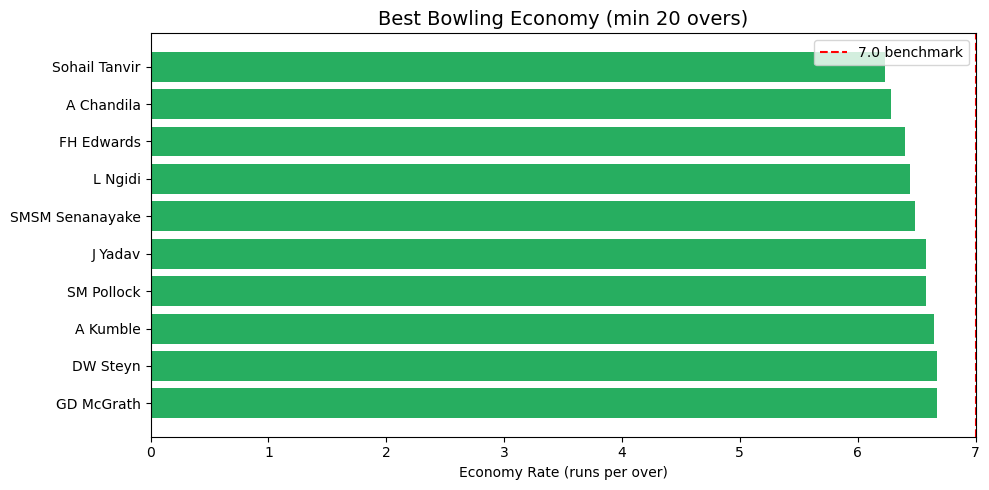

In [6]:
# Bowling economy = runs conceded / overs bowled
# Economy formula: (total_runs / balls_bowled) * 6

bowling = deliveries.groupby('bowler').agg(
    balls  = ('ball', 'count'),          # total balls
    runs   = ('total_runs', 'sum'),       # runs conceded
    wickets= ('player_dismissed', 'count')# wickets
).reset_index()

# Derived columns
bowling['overs']   = bowling['balls'] / 6
bowling['economy'] = (bowling['runs'] / bowling['balls'] * 6).round(2)

# Filter: minimum 20 overs bowled (quality threshold)
qualified = bowling[bowling['overs'] >= 20]
best_economy = qualified.nsmallest(10, 'economy')
print(best_economy[['bowler', 'overs', 'runs', 'wickets', 'economy']])

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#27ae60' if e < 7 else '#f39c12'
          for e in best_economy['economy']]
ax.barh(best_economy['bowler'], best_economy['economy'], color=colors)
ax.set_title('Best Bowling Economy (min 20 overs)', fontsize=14)
ax.set_xlabel('Economy Rate (runs per over)')
ax.invert_yaxis()
ax.axvline(7, color='red', ls='--', label='7.0 benchmark')
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
# Win rate by toss decision — using matches.csv

# Derived column: did toss winner also win the match?
matches['toss_win_match_win'] = (
    matches['toss_winner'] == matches['winner']
).astype(int)

# Win rate: group by team AND toss decision
toss_win = matches.groupby(['toss_winner', 'toss_decision'])['toss_win_match_win'].mean()

# Pivot for clean display
toss_pivot = matches.pivot_table(
    index='toss_decision',
    values='toss_win_match_win',
    aggfunc='mean'
).round(3)
print("Win rate after choosing to bat vs field:")
print(toss_pivot)

# Per-team win rates
team_win = matches.groupby('toss_winner')['toss_win_match_win'].agg(
    ['mean', 'count']
).round(3).sort_values('mean', ascending=False)
print(team_win.head(8))

Win rate after choosing to bat vs field:
               toss_win_match_win
toss_decision                    
bat                         0.457
field                       0.559
                              mean  count
toss_winner                              
Rising Pune Supergiant       0.833      6
Delhi Capitals               0.700     10
Gujarat Lions                0.667     15
Chennai Super Kings          0.640     89
Kolkata Knight Riders        0.576     92
Mumbai Indians               0.571     98
Rajasthan Royals             0.525     80
Royal Challengers Bangalore  0.506     81


In [5]:
# ── Highest Partnerships ────────────────────────────────
partnerships = (
    deliveries
    .groupby(['match_id', 'inning', 'batsman', 'non_striker'])['batsman_runs']
    .sum()
    .reset_index()
    .rename(columns={'batsman_runs': 'partnership_runs'})
)

# Sort alphabetically so A-B and B-A are the same pair
partnerships['pair'] = partnerships.apply(
    lambda r: ' & '.join(sorted([r['batsman'], r['non_striker']])), axis=1)
top_partnerships = partnerships.nlargest(10, 'partnership_runs')
print(top_partnerships[['pair', 'partnership_runs', 'match_id']])

# ── Player of Match Awards ───────────────────────────────
pom = (
    matches['player_of_match']
    .value_counts()
    .head(10)
    .reset_index()
)
pom.columns = ['player', 'awards']
print(pom)

# ── Master Summary DataFrame ─────────────────────────────
summary = pd.DataFrame({
    'metric': ['Total deliveries', 'Total matches',
               'Seasons covered', 'Unique batsmen',
               'Unique bowlers', 'Top scorer', 'Most POM awards'],
    'value': [
        len(deliveries),
        len(matches),
        matches['season'].nunique(),
        deliveries['batsman'].nunique(),
        deliveries['bowler'].nunique(),
        top_scorers.iloc[0]['batsman'],
        pom.iloc[0]['player']
    ]
})
print(summary)

                            pair  partnership_runs  match_id
14035   AB de Villiers & V Kohli               133       562
15407   AB de Villiers & V Kohli               129       620
9300          CH Gayle & V Kohli               127       372
10323      CH Gayle & TM Dilshan               127       411
17605     DA Warner & J Bairstow               115     11147
1821   AC Gilchrist & VVS Laxman               109        72
8338         DA Warner & NV Ojha               109       331
9086        HH Gibbs & RG Sharma               109       363
7443     AC Gilchrist & SE Marsh               105       296
888         DA Warner & S Dhawan               104        36
           player  awards
0        CH Gayle      21
1  AB de Villiers      20
2        MS Dhoni      17
3       RG Sharma      17
4       DA Warner      17
5       YK Pathan      16
6       SR Watson      15
7        SK Raina      14
8       G Gambhir      13
9      MEK Hussey      12
             metric     value
0  Total deli